## Objective

The objective of this notebook is to evaluate the trained models and choose the best one for the stock forecasting task.

In this notebook, I will:

* Compare the Random Forest and XGBoost models.
* Evaluate the prediction error by product.
* Analyze the best and worst predictions.
* Check if the model is useful for stock recommendation.
* Choose the final model to be used in the next phase.

The main metrics used in this evaluation are:

* MAE
* RMSE
* MAPE


In [1]:
import os 
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.dates as mdates
import joblib
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
os.chdir(ROOT)
sys.path.append(str(ROOT))
from src.evaluation import evaluate_forecast, error_by_product
from src.importance import get_feature_importance

DATA_PATH = Path("data/processed/modeling_dataset.csv")
MODELS_PATH = ROOT / "artifacts" / "models"

rf_model = joblib.load(MODELS_PATH / "random_forest_model.pkl")
xgb_model = joblib.load(MODELS_PATH / "xgboost_model.pkl")

df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print("columns:", list(df.columns))
print(f"Date range: {df['sale_date'].min()} to {df['sale_date'].max()}")
df.head()

shape: (6000, 16)
columns: ['product_name', 'sale_date', 'quantity_sold', 'unit_price_brl', 'day_of_week', 'day_of_month', 'month', 'week_of_year', 'is_weekend', 'quantity_1d', 'quantity_7d', 'quantity_14d', 'rolling_1d', 'rolling_7d', 'rolling_14d', 'weather_condition']
Date range: 2025-01-15 to 2026-05-29


,product_name,sale_date,quantity_sold,unit_price_brl,day_of_week,day_of_month,month,week_of_year,is_weekend,quantity_1d,quantity_7d,quantity_14d,rolling_1d,rolling_7d,rolling_14d,weather_condition
0,Bag Delivery 45L,2025-01-15,5.0,179.1025,2,15,1,3,0,7.0,6.0,5.0,7.0,4.428571,4.071429,Ensolarado
1,Bag Delivery 45L,2025-01-16,4.0,179.2300,3,16,1,3,0,5.0,3.0,2.0,5.0,4.285714,4.071429,Ensolarado
2,Bag Delivery 45L,2025-01-17,4.0,179.7700,4,17,1,3,0,4.0,2.0,1.0,4.0,4.428571,4.214286,Chuva Leve
3,Bag Delivery 45L,2025-01-18,3.0,175.6100,5,18,1,3,1,4.0,4.0,3.0,4.0,4.714286,4.428571,Ensolarado
4,Bag Delivery 45L,2025-01-19,0.0,175.6100,6,19,1,3,1,3.0,5.0,8.0,3.0,4.571429,4.428571,Nublado


## Recreating the Same Temporal Split

In [2]:
df["sale_date"] = pd.to_datetime(df["sale_date"])

unique_dates = df["sale_date"].sort_values().unique()

split = int(len(unique_dates) * 0.8)

train_period = unique_dates[:split]
test_period = unique_dates[split:]

print(f"Train period: {train_period.min()} to {train_period.max()}")
print(f"Test period: {test_period.min()} to {test_period.max()}") 

train = df[df["sale_date"].isin(train_period)].copy()
test = df[df["sale_date"].isin(test_period)].copy()

Train period: 2025-01-15 00:00:00 to 2026-02-18 00:00:00
Test period: 2026-02-19 00:00:00 to 2026-05-29 00:00:00


In [3]:
target = "quantity_sold"
numeric_features = [
    "unit_price_brl",
    "day_of_week",
    "day_of_month",
    "month",
    "week_of_year",
    "is_weekend",
    "quantity_1d",
    "quantity_7d",
    "quantity_14d",
    "rolling_1d",
    "rolling_7d",
    "rolling_14d",
]
categorical_features = ["product_name", "weather_condition"]

X_train = train.loc[:, numeric_features + categorical_features]
y_train = train[target]

X_test = test.loc[:, numeric_features + categorical_features]
y_test = test[target].to_numpy()

## Generating Predictions

In [4]:
y_pred_rf = rf_model.predict(X_test)
y_pred_rf = np.clip(y_pred_rf, 0, None)

rf_results = evaluate_forecast(y_test, y_pred_rf)

print(f"MAE: {rf_results['MAE']:.2f}")
print(f"RMSE: {rf_results['RMSE']:.2f}")
print(f"MAPE: {rf_results['MAPE']:.2f}%")

MAE: 1.30
RMSE: 1.82
MAPE: 60.31%


In [5]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

xgb_results = evaluate_forecast(y_test, y_pred_xgb)

print(f"MAE: {xgb_results['MAE']:.2f}")
print(f"RMSE: {xgb_results['RMSE']:.2f}")
print(f"MAPE: {xgb_results['MAPE']:.2f}%")

MAE: 1.27
RMSE: 1.83
MAPE: 59.56%


## Validating the Prediction Values
Note: Negative predictions were clipped to zero because demand quantity cannot be negative.

In [6]:
prediction_summary_df = pd.DataFrame([
    {
        "model": "Random Forest",
        "lowest_prediction": np.min(y_pred_rf),
        "highest_prediction": np.max(y_pred_rf),
    },
    {
        "model": "XGBoost",
        "lowest_prediction": np.min(y_pred_xgb),
        "highest_prediction": np.max(y_pred_xgb),
    }
])

prediction_summary_df

,model,lowest_prediction,highest_prediction
0,Random Forest,0.0,5.789805
1,XGBoost,0.0,5.333206


## Overall Model Metrics

In [7]:
metrics_df = pd.DataFrame([
    {
    "Model": "Random Forest",
    "MAE": rf_results['MAE'],
    "RMSE": rf_results['RMSE'],
    "MAPE":  rf_results['MAPE']
    },
    {
    "Model": "XGBoost",
    "MAE": xgb_results['MAE'],
    "RMSE": xgb_results['RMSE'],
    "MAPE":  xgb_results['MAPE']
    }
]).round(2)

metrics_df

,Model,MAE,RMSE,MAPE
0,Random Forest,1.30,1.82,60.31
1,XGBoost,1.27,1.83,59.56


In [8]:
# Evaluation metrics are exported in the final reports section.
metrics_df

,Model,MAE,RMSE,MAPE
0,Random Forest,1.30,1.82,60.31
1,XGBoost,1.27,1.83,59.56


## Comparing With Training Results

In [9]:
training_results_path = ROOT / "reports" / "model_training_results.csv"

training_results_df = pd.read_csv(training_results_path)

training_results_df

,Model,MAE,RMSE,MAPE
0,Random Forest,1.30,1.82,60.31
1,XGBoost,1.27,1.83,59.56


In [10]:
comparison_df = training_results_df.merge(
    metrics_df,
    on="Model",
    suffixes=("_training", "_evaluation")
)

comparison_df["MAE_diff"] = (
    comparison_df["MAE_evaluation"] - comparison_df["MAE_training"]
)

comparison_df["RMSE_diff"] = (
    comparison_df["RMSE_evaluation"] - comparison_df["RMSE_training"]
)

comparison_df["MAPE_diff"] = (
    comparison_df["MAPE_evaluation"] - comparison_df["MAPE_training"]
)

comparison_df = comparison_df.round(2)

comparison_df

,Model,MAE_training,RMSE_training,MAPE_training,MAE_evaluation,RMSE_evaluation,MAPE_evaluation,MAE_diff,RMSE_diff,MAPE_diff
0,Random Forest,1.30,1.82,60.31,1.30,1.82,60.31,0.0,0.0,0.0
1,XGBoost,1.27,1.83,59.56,1.27,1.83,59.56,0.0,0.0,0.0


## Evaluate Error by Product

In [11]:
eval_df = test[["sale_date", "product_name", "quantity_sold"]].reset_index(drop=True).copy()

eval_df["rf_prediction"] = np.asarray(y_pred_rf).ravel()
eval_df["xgb_prediction"] = np.asarray(y_pred_xgb).ravel()

product_results = []

for product_name, product_df in eval_df.groupby("product_name"):
    product_results.append(
        error_by_product(
            product_df=product_df,
            prediction_col="rf_prediction",
            model_name="Random Forest"
        )
    )

    product_results.append(
        error_by_product(
            product_df=product_df,
            prediction_col="xgb_prediction",
            model_name="XGBoost"
        )
    )

product_error_df = pd.DataFrame(product_results)

product_error_df = product_error_df.round({
    "MAE": 2,
    "RMSE": 2,
    "MAPE": 2,
    "total_actual_quantity": 2,
    "total_predicted_quantity": 2
})

product_error_df.head() 



,product_name,model_name,MAE,RMSE,MAPE,total_actual_quantity,total_predicted_quantity,error_direction
0,Bag Delivery 45L,Random Forest,2.32,3.08,70.92,402.0,343.82,Underprediction
1,Bag Delivery 45L,XGBoost,2.36,3.16,69.65,402.0,323.41,Underprediction
2,Bag Delivery 80L,Random Forest,1.55,1.84,59.42,152.0,148.05,Underprediction
3,Bag Delivery 80L,XGBoost,1.50,1.85,53.05,152.0,132.41,Underprediction
4,Balaclava,Random Forest,1.00,1.27,40.51,90.0,103.16,Overprediction


## Identify Best and Worst Products

In [12]:
product_error_df["total_error"] = (
    product_error_df["total_predicted_quantity"]
    - product_error_df["total_actual_quantity"]
)

In [13]:
best_products = (
    product_error_df
    .sort_values("RMSE", ascending=True)
    .head(10)
)

best_products

,product_name,model_name,MAE,RMSE,MAPE,total_actual_quantity,total_predicted_quantity,error_direction,total_error
17,Intercomunicador,XGBoost,0.21,0.54,90.22,13.0,9.84,Underprediction,-3.16
16,Intercomunicador,Random Forest,0.29,0.58,87.14,13.0,18.21,Overprediction,5.21
11,Capacete LS2,XGBoost,0.43,0.72,86.42,29.0,19.88,Underprediction,-9.12
10,Capacete LS2,Random Forest,0.52,0.74,73.12,29.0,37.12,Overprediction,8.12
20,Retrovisor Esportivo,Random Forest,0.74,0.99,50.80,58.0,60.98,Overprediction,2.98
21,Retrovisor Esportivo,XGBoost,0.75,1.00,58.22,58.0,54.24,Underprediction,-3.76
5,Balaclava,XGBoost,0.94,1.25,38.95,90.0,89.15,Underprediction,-0.85
4,Balaclava,Random Forest,1.00,1.27,40.51,90.0,103.16,Overprediction,13.16
14,Carregador USB Moto,Random Forest,1.06,1.49,54.36,91.0,73.39,Underprediction,-17.61
15,Carregador USB Moto,XGBoost,1.06,1.50,59.47,91.0,68.20,Underprediction,-22.80


In [14]:
worst_products = (
    product_error_df
    .sort_values("RMSE", ascending=False)
    .head(10)
)

worst_products

,product_name,model_name,MAE,RMSE,MAPE,total_actual_quantity,total_predicted_quantity,error_direction,total_error
1,Bag Delivery 45L,XGBoost,2.36,3.16,69.65,402.0,323.41,Underprediction,-78.59
0,Bag Delivery 45L,Random Forest,2.32,3.08,70.92,402.0,343.82,Underprediction,-58.18
8,Capa de Chuva,Random Forest,2.07,2.46,79.85,241.0,253.14,Overprediction,12.14
23,Suporte Celular Moto,XGBoost,1.86,2.45,71.77,312.0,322.26,Overprediction,10.26
9,Capa de Chuva,XGBoost,2.00,2.41,72.73,241.0,234.25,Underprediction,-6.75
22,Suporte Celular Moto,Random Forest,1.85,2.38,73.32,312.0,329.91,Overprediction,17.91
12,Capacete Pro Tork,Random Forest,1.51,1.97,43.22,189.0,178.87,Underprediction,-10.13
13,Capacete Pro Tork,XGBoost,1.51,1.95,45.53,189.0,165.28,Underprediction,-23.72
3,Bag Delivery 80L,XGBoost,1.50,1.85,53.05,152.0,132.41,Underprediction,-19.59
2,Bag Delivery 80L,Random Forest,1.55,1.84,59.42,152.0,148.05,Underprediction,-3.95


In [15]:
underpredicted_products = (
    product_error_df[product_error_df["total_error"] < 0]
    .assign(underprediction_amount=lambda df: df["total_error"].abs())
    .sort_values("underprediction_amount", ascending=False)
    .head(10)
)

underpredicted_products

,product_name,model_name,MAE,RMSE,MAPE,total_actual_quantity,total_predicted_quantity,error_direction,total_error,underprediction_amount
1,Bag Delivery 45L,XGBoost,2.36,3.16,69.65,402.0,323.41,Underprediction,-78.59,78.59
0,Bag Delivery 45L,Random Forest,2.32,3.08,70.92,402.0,343.82,Underprediction,-58.18,58.18
7,Baú Moto 30L,XGBoost,1.15,1.51,44.62,130.0,106.08,Underprediction,-23.92,23.92
13,Capacete Pro Tork,XGBoost,1.51,1.95,45.53,189.0,165.28,Underprediction,-23.72,23.72
15,Carregador USB Moto,XGBoost,1.06,1.50,59.47,91.0,68.20,Underprediction,-22.80,22.80
3,Bag Delivery 80L,XGBoost,1.50,1.85,53.05,152.0,132.41,Underprediction,-19.59,19.59
14,Carregador USB Moto,Random Forest,1.06,1.49,54.36,91.0,73.39,Underprediction,-17.61,17.61
6,Baú Moto 30L,Random Forest,1.19,1.56,45.19,130.0,117.10,Underprediction,-12.90,12.90
12,Capacete Pro Tork,Random Forest,1.51,1.97,43.22,189.0,178.87,Underprediction,-10.13,10.13
11,Capacete LS2,XGBoost,0.43,0.72,86.42,29.0,19.88,Underprediction,-9.12,9.12


In [16]:
overpredicted_products = (
    product_error_df[product_error_df["total_error"] > 0]
    .assign(overprediction_amount=lambda df: df["total_error"])
    .sort_values("overprediction_amount", ascending=False)
    .head(10)
)

overpredicted_products

,product_name,model_name,MAE,RMSE,MAPE,total_actual_quantity,total_predicted_quantity,error_direction,total_error,overprediction_amount
19,Luva Motoboy,XGBoost,1.45,1.79,53.64,231.0,254.27,Overprediction,23.27,23.27
18,Luva Motoboy,Random Forest,1.47,1.80,55.07,231.0,252.25,Overprediction,21.25,21.25
22,Suporte Celular Moto,Random Forest,1.85,2.38,73.32,312.0,329.91,Overprediction,17.91,17.91
4,Balaclava,Random Forest,1.00,1.27,40.51,90.0,103.16,Overprediction,13.16,13.16
8,Capa de Chuva,Random Forest,2.07,2.46,79.85,241.0,253.14,Overprediction,12.14,12.14
23,Suporte Celular Moto,XGBoost,1.86,2.45,71.77,312.0,322.26,Overprediction,10.26,10.26
10,Capacete LS2,Random Forest,0.52,0.74,73.12,29.0,37.12,Overprediction,8.12,8.12
16,Intercomunicador,Random Forest,0.29,0.58,87.14,13.0,18.21,Overprediction,5.21,5.21
20,Retrovisor Esportivo,Random Forest,0.74,0.99,50.80,58.0,60.98,Overprediction,2.98,2.98


## Prediction Error Distribution by Model

In [17]:
eval_df["rf_error"] = (
    eval_df["quantity_sold"]
    - eval_df["rf_prediction"]
)

eval_df["rf_abs_error"] = eval_df["rf_error"].abs()

eval_df["xgb_error"] = (
    eval_df["quantity_sold"]
    - eval_df["xgb_prediction"]
)

eval_df["xgb_abs_error"] = eval_df["xgb_error"].abs()

rf_mae = mean_absolute_error(
    eval_df["quantity_sold"],
    eval_df["rf_prediction"]
)

xgb_mae = mean_absolute_error(
    eval_df["quantity_sold"],
    eval_df["xgb_prediction"]
)

eval_df.head()

,sale_date,product_name,quantity_sold,rf_prediction,xgb_prediction,rf_error,rf_abs_error,xgb_error,xgb_abs_error
0,2026-02-19,Bag Delivery 45L,3.0,2.501140,2.639087,0.498860,0.498860,0.360913,0.360913
1,2026-02-20,Bag Delivery 45L,3.0,2.223636,2.142377,0.776364,0.776364,0.857623,0.857623
2,2026-02-21,Bag Delivery 45L,3.0,2.890409,2.641507,0.109591,0.109591,0.358493,0.358493
3,2026-02-22,Bag Delivery 45L,16.0,3.509952,3.197616,12.490048,12.490048,12.802384,12.802384
4,2026-02-23,Bag Delivery 45L,4.0,3.242818,2.447279,0.757182,0.757182,1.552721,1.552721


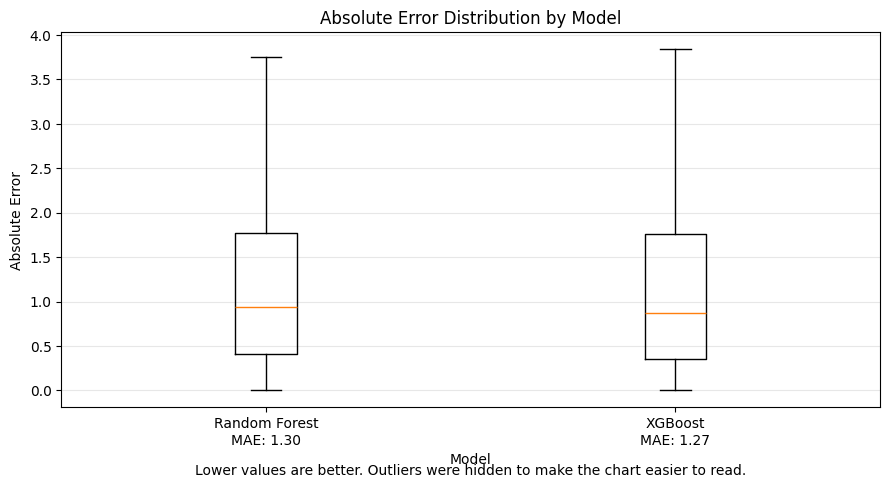

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    [
        eval_df["rf_abs_error"],
        eval_df["xgb_abs_error"]
    ],
    tick_labels=[
        f"Random Forest\nMAE: {rf_mae:.2f}",
        f"XGBoost\nMAE: {xgb_mae:.2f}"
    ],
    showfliers=False
)

ax.set_title("Absolute Error Distribution by Model")
ax.set_ylabel("Absolute Error")
ax.set_xlabel("Model")

ax.grid(axis="y", alpha=0.3)

ax.text(
    0.5,
    -0.18,
    "Lower values are better. Outliers were hidden to make the chart easier to read.",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

## Visual Evaluation by Product

In [19]:
product_summary = (
    eval_df
    .groupby("product_name")
    .agg(
        total_actual_quantity=("quantity_sold", "sum"),
        avg_actual_quantity=("quantity_sold", "mean"),
        rf_mae=("rf_abs_error", "mean"),
        xgb_mae=("xgb_abs_error", "mean")
    )
    .reset_index()
)

product_summary["best_model_mae"] = (
    product_summary[["rf_mae", "xgb_mae"]]
    .min(axis=1)
)

product_summary.sort_values("total_actual_quantity", ascending=False).head()

,product_name,total_actual_quantity,avg_actual_quantity,rf_mae,xgb_mae,best_model_mae
0,Bag Delivery 45L,402.0,4.02,2.315640,2.363998,2.315640
11,Suporte Celular Moto,312.0,3.12,1.852499,1.862727,1.852499
4,Capa de Chuva,241.0,2.41,2.070366,2.000166,2.000166
9,Luva Motoboy,231.0,2.31,1.471064,1.451536,1.451536
6,Capacete Pro Tork,189.0,1.89,1.508012,1.512908,1.508012


In [20]:
high_sales_product = (
    product_summary
    .sort_values("total_actual_quantity", ascending=False)
    .iloc[0]["product_name"]
)

low_sales_product = (
    product_summary[product_summary["total_actual_quantity"] > 0]
    .sort_values("total_actual_quantity", ascending=True)
    .iloc[0]["product_name"]
)

selected_products = [high_sales_product, low_sales_product]

high_error_candidates = (
    product_summary
    .sort_values("best_model_mae", ascending=False)["product_name"]
    .tolist()
)

for product_name in high_error_candidates:
    if product_name not in selected_products:
        selected_products.append(product_name)
        break

selected_products

['Bag Delivery 45L', 'Intercomunicador', 'Capa de Chuva']

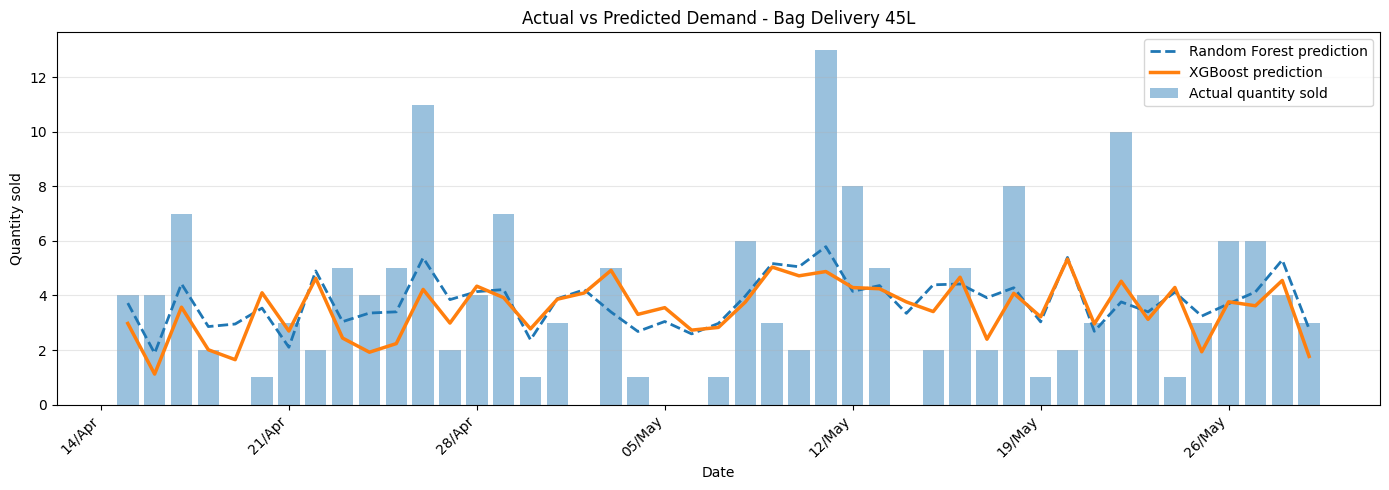

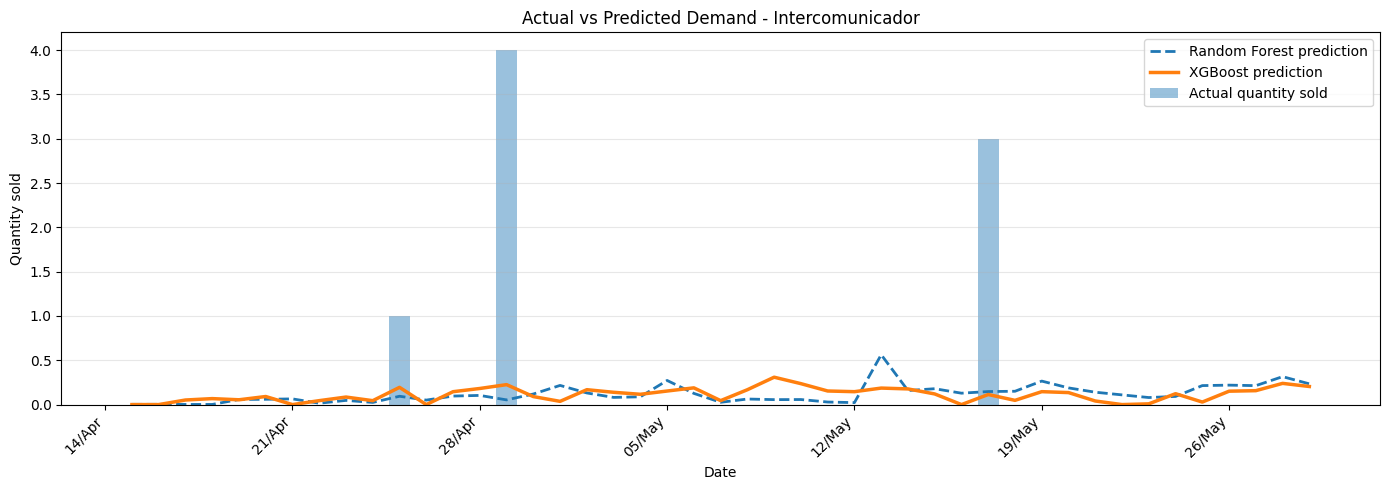

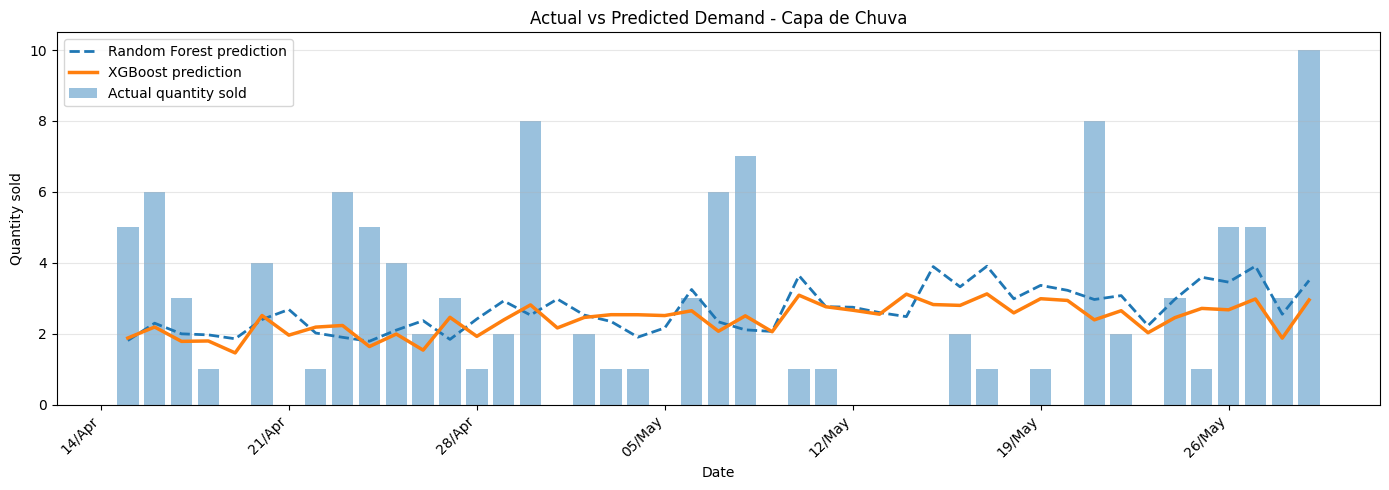

In [21]:
def plot_product_predictions(product_name, last_n_days=45):
    product_df = (
        eval_df[eval_df["product_name"] == product_name]
        .sort_values("sale_date")
        .tail(last_n_days)
        .copy()
    )

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.bar(
        product_df["sale_date"],
        product_df["quantity_sold"],
        label="Actual quantity sold",
        alpha=0.45
    )

    ax.plot(
        product_df["sale_date"],
        product_df["rf_prediction"],
        linestyle="--",
        linewidth=2,
        label="Random Forest prediction"
    )

    ax.plot(
        product_df["sale_date"],
        product_df["xgb_prediction"],
        linestyle="-",
        linewidth=2.5,
        label="XGBoost prediction"
    )

    ax.set_title(f"Actual vs Predicted Demand - {product_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Quantity sold")

    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))

    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
for product in selected_products:
    plot_product_predictions(product)

## Final Feature Importance

In [22]:
rf_importance = get_feature_importance(rf_model)
xgb_importance = get_feature_importance(xgb_model)

importance_df = rf_importance.merge(
    xgb_importance,
    on="feature",
    suffixes=("_rf", "_xgb")
)

importance_df.head(5)


,feature,importance_rf,importance_xgb
0,rolling_14d,0.317605,0.112770
1,unit_price_brl,0.174383,0.045036
2,day_of_month,0.083010,0.031290
3,week_of_year,0.075886,0.034673
4,rolling_7d,0.064493,0.055682


## Save Evaluation Reports

In [23]:
reports_path = ROOT / "reports"
reports_path.mkdir(parents=True, exist_ok=True)

prediction_cols = [
    "sale_date",
    "product_name",
    "quantity_sold",
    "rf_prediction",
    "xgb_prediction",
    "rf_error",
    "xgb_error",
    "rf_abs_error",
    "xgb_abs_error"
]

predictions_comparison_df = eval_df[prediction_cols].copy()

predictions_comparison_df.to_csv(
    reports_path / "predictions_comparison.csv",
    index=False,
    encoding="utf-8"
)

model_evaluation_summary_df = pd.DataFrame([
    {
        "model_name": "Random Forest",
        "MAE": rf_results["MAE"],
        "RMSE": rf_results["RMSE"],
        "MAPE": rf_results["MAPE"]
    },
    {
        "model_name": "XGBoost",
        "MAE": xgb_results["MAE"],
        "RMSE": xgb_results["RMSE"],
        "MAPE": xgb_results["MAPE"]
    }
])

model_evaluation_summary_df.to_csv(
    reports_path / "model_evaluation_summary.csv",
    index=False,
    encoding="utf-8"
)

product_error_df.to_csv(
    reports_path / "model_evaluation_by_product.csv",
    index=False,
    encoding="utf-8"
)

importance_df.to_csv(
    reports_path / "feature_importance_final.csv",
    index=False,
    encoding="utf-8"
)

print("Saved evaluation reports to:", reports_path.resolve())

Saved evaluation reports to: C:\DEV\motostock-ai\reports


## Model Evaluation Conclusion

In this notebook, the Random Forest and XGBoost models were loaded from the trained model artifacts and evaluated on the temporal test set.

Both models showed similar overall performance on the temporal test set. Random Forest had a slightly better RMSE, while XGBoost had a slightly better MAE and MAPE.

Since this project is focused on stock recommendation, MAE is one of the most important metrics because it shows the average error in units sold. A lower MAE means the model usually makes smaller mistakes when predicting product demand.

Based on the results, the selected final model is **XGBoost**.

XGBoost was chosen because it had the lowest MAE, meaning that it made slightly better predictions on average. The difference between XGBoost and Random Forest was small, but XGBoost performed better in the main metric used for this project.

The visual evaluation and feature importance analysis also showed that the models were able to use historical demand features, such as lag and rolling features, to learn useful sales patterns.

In the next phase, the selected XGBoost model will be used to support the stock recommendation system.